In [1]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

## Load and Visualize the Data


In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
set_seed(17)

In [3]:
class DBSCANFrameDataset(Dataset):
    def __init__(self, data_dir):
        """
        Loads all .mat files from a pre-split directory.
        Each sample is one frame: tensor of shape [N_pixels, 4] (x, y, GFP, RFP).
        """
        self.data_dir = data_dir
        self.file_list = sorted([
            f for f in os.listdir(data_dir) if f.endswith('.mat')
        ])
        print(f"Found {len(self.file_list)} frames in {data_dir}")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.file_list[idx])
        mat  = scipy.io.loadmat(path)
        features = mat['features'].astype(np.float32)  # [N_pixels, 4]
        return torch.tensor(features)

# --- Paths ---
base_dir = '/Users/vedhasyamuvva/Desktop/ML4P/FinalProject/data'

# --- Datasets ---
train_dataset = DBSCANFrameDataset(os.path.join(base_dir, 'train_data'))
val_dataset   = DBSCANFrameDataset(os.path.join(base_dir, 'validation_data'))
test_dataset  = DBSCANFrameDataset(os.path.join(base_dir, 'test_data'))

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

Found 1000 frames in /Users/vedhasyamuvva/Desktop/ML4P/FinalProject/data/train_data
Found 300 frames in /Users/vedhasyamuvva/Desktop/ML4P/FinalProject/data/validation_data
Found 300 frames in /Users/vedhasyamuvva/Desktop/ML4P/FinalProject/data/test_data


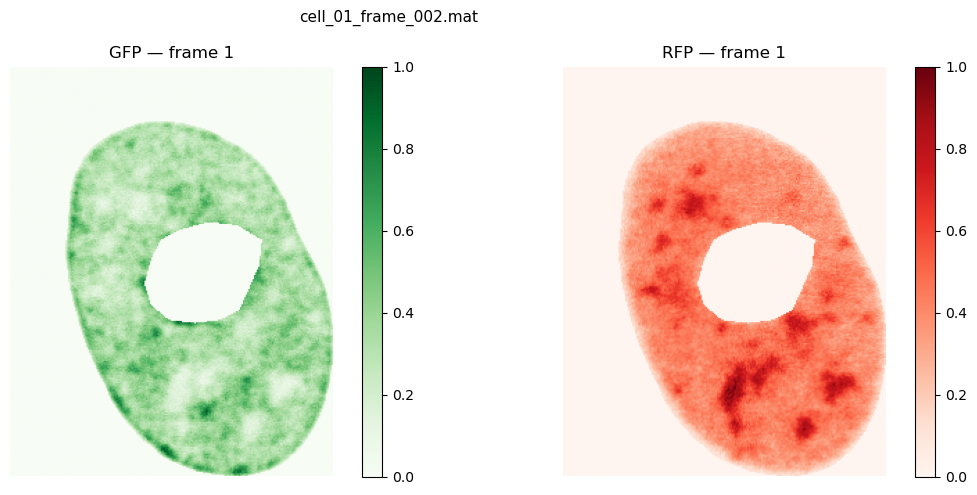

In [4]:
def visualize_frame(dataset, idx=0):
    """
    Reconstructs and plots GFP and RFP channels separately for one frame.
    features columns: [x, y, RFP, GFP]
    """
    features = dataset[idx].numpy()

    col = features[:, 0].astype(int) - 1  # meshgrid X = columns
    row = features[:, 1].astype(int) - 1  # meshgrid Y = rows

    nRows = row.max() + 1
    nCols = col.max() + 1

    gfp_img = np.zeros((nRows, nCols), dtype=np.float32)
    rfp_img = np.zeros((nRows, nCols), dtype=np.float32)

    gfp_img[row, col] = features[:, 2]
    rfp_img[row, col] = features[:, 3]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    im0 = axes[0].imshow(gfp_img, cmap='Greens', vmin=0, vmax=1)
    axes[0].set_title(f'GFP — frame {idx}')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(rfp_img, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title(f'RFP — frame {idx}')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    fname = dataset.file_list[idx]
    fig.suptitle(fname, fontsize=11)
    plt.tight_layout()
    plt.show()

# View first frame of training set
idx = 1 #frames go from 0 to 100
visualize_frame(train_dataset, idx=idx)


##  DBSCAN

In [ ]:
def run_dbscan_on_frame(features, eps=0.5, min_samples=10, channel='both'):
    """
    channel: 'both' | 'gfp' | 'rfp'
    features columns: [x, y, GFP, RFP]
    """
    features_scaled = features.copy()
    features_scaled[:, 0] /= 325
    features_scaled[:, 1] /= 325

    if channel == 'both':
        data = features_scaled[:, :4]      # x, y, RFP, GFP
    elif channel == 'gfp':
        data = features_scaled[:, [0, 1, 2]]  # x, y, GFP only
    elif channel == 'rfp':
        data = features_scaled[:, [0, 1, 3]]  # x, y, RFP only
    else:
        raise ValueError("channel must be 'both', 'gfp', or 'rfp'")

    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(data)
    return labels

In [ ]:

def visualize_clusters(features, labels, EPS, frame_name=''):
    """
    Reconstructs 2D images and clusters 
    """
    col = features[:, 0].astype(int) - 1
    row = features[:, 1].astype(int) - 1
    nRows = row.max() + 1
    nCols = col.max() + 1

    gfp_img    = np.zeros((nRows, nCols), dtype=np.float32)
    rfp_img    = np.zeros((nRows, nCols), dtype=np.float32)
    label_img  = np.full((nRows, nCols), -1, dtype=int)

    gfp_img[row, col]   = features[:, 2]
    rfp_img[row, col]   = features[:, 3]
    label_img[row, col] = labels

    cluster_overlay = np.ma.masked_where(label_img == -1, label_img)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].imshow(gfp_img, cmap='Greens', vmin=0, vmax=1)
    axes[0].axis('off')

    axes[1].imshow(rfp_img, cmap='Reds', vmin=0, vmax=1)
    axes[1].axis('off')

    axes[2].imshow(cluster_overlay, cmap='tab20', alpha=0.5,
                   vmin=0, vmax=labels.max() if labels.max() > 0 else 1)
    axes[2].axis('off')

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    fig.suptitle(f'{n_clusters} clusters found, {n_noise} noise pixels, eps = {EPS}', fontsize=11)
    fig.text(0.5, 0.92, frame_name, ha='center', fontsize=9, color='gray')
    plt.tight_layout()
    plt.show()

    return n_clusters, n_noise

In [ ]:

def visualize_ONLY_clusters(fig, axes,i, features, labels, EPS, frame_name=''):
    """
    Plot just the clusters
    """
    col = features[:, 0].astype(int) - 1
    row = features[:, 1].astype(int) - 1
    nRows = row.max() + 1
    nCols = col.max() + 1

    gfp_img    = np.zeros((nRows, nCols), dtype=np.float32)
    rfp_img    = np.zeros((nRows, nCols), dtype=np.float32)
    label_img  = np.full((nRows, nCols), -1, dtype=int)

    gfp_img[row, col]   = features[:, 2]
    rfp_img[row, col]   = features[:, 3]
    label_img[row, col] = labels

    # Mask noise pixels (label == -1) for the overlay
    cluster_overlay = np.ma.masked_where(label_img == -1, label_img)

    axes[i].imshow(cluster_overlay, cmap='tab20', alpha=0.5,
                   vmin=0, vmax=labels.max() if labels.max() > 0 else 1)
    axes[i].axis('off')

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()

    return n_clusters, n_noise

In [32]:
# For Future Work to understand the clusters and their distribution

def visualize_cluster_histograms(features, labels, eps, frame_name=''):
    """
    Plots GFP and RFP intensity histograms for each cluster separately.
    Noise pixels (label == -1) are shown in gray for reference.
    """
    unique_labels = sorted(set(labels))
    n_clusters    = len(unique_labels) - (1 if -1 in unique_labels else 0)

    cmap   = plt.cm.cool
    colors = [cmap(i / max(n_clusters, 1)) for i in range(n_clusters)]

    fig, axes = plt.subplots(n_clusters + 1, 2,
                             figsize=(12, 3 * (n_clusters + 1)))

    # Row 0: noise pixels for reference
    noise_mask = labels == -1
    axes[0, 0].hist(features[noise_mask, 2], bins=50, color='black', alpha=0.7)
    axes[0, 0].set_title('Noise — GFP')
    axes[0, 0].set_xlabel('Intensity')
    axes[0, 0].set_ylabel('Pixel count')

    axes[0, 1].hist(features[noise_mask, 3], bins=50, color='black', alpha=0.7)
    axes[0, 1].set_title('Noise — RFP')
    axes[0, 1].set_xlabel('Intensity')

    # One row per cluster
    for i, label in enumerate(l for l in unique_labels if l != -1):
        cluster_mask = labels == label
        color        = colors[i]
        n_pixels     = cluster_mask.sum()

        axes[i+1, 0].hist(features[cluster_mask, 2], bins=50,
                          color=color, alpha=0.8)
        axes[i+1, 0].set_title(f'Cluster {label} — GFP  ({n_pixels} px)')
        axes[i+1, 0].set_xlabel('Intensity')
        axes[i+1, 0].set_ylabel('Pixel count')
        axes[i+1, 0].set_xlim(0, 1)

        axes[i+1, 1].hist(features[cluster_mask, 3], bins=50,
                          color=color, alpha=0.8)
        axes[i+1, 1].set_title(f'Cluster {label} — RFP  ({n_pixels} px)')
        axes[i+1, 1].set_xlabel('Intensity')
        axes[i+1, 1].set_xlim(0, 1)

    fig.suptitle(f'{n_clusters} clusters, eps={eps}', fontsize=12)
    fig.text(0.5, 0.97, frame_name, ha='center', fontsize=9, color='gray')
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()


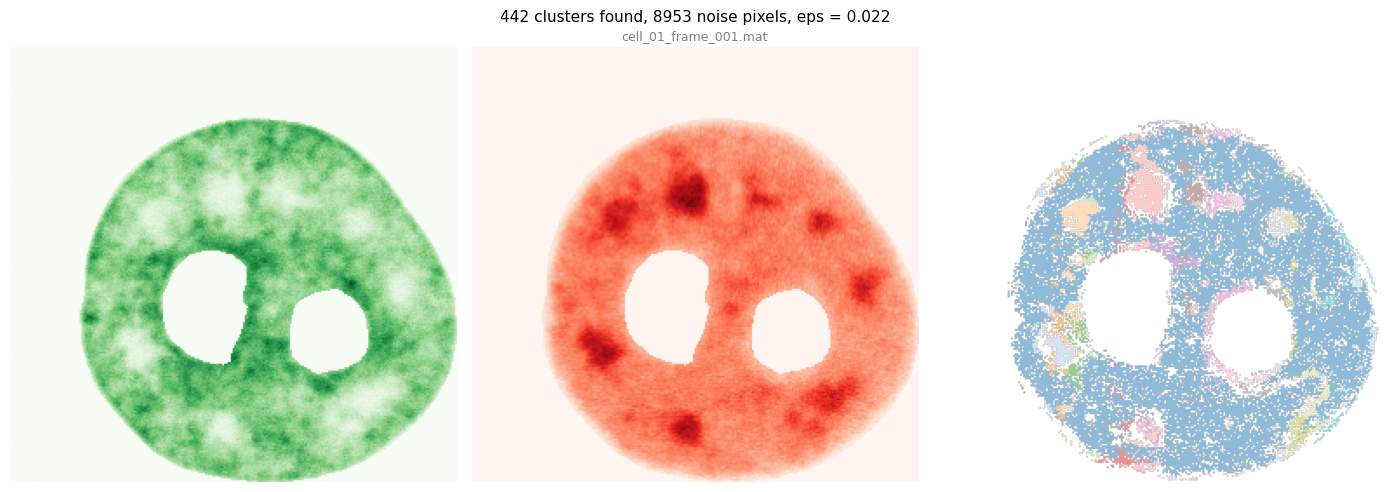

In [ ]:

# --- Run on a single frame to tune eps and min_samples ---
idx = 400# 0 to 999
EPS = 0.022
MIN_SAMPLES = 5
features = train_dataset[idx].numpy()
labels   = run_dbscan_on_frame(features, eps=EPS, min_samples=MIN_SAMPLES, channel = 'both') 
n_clusters, n_noise = visualize_clusters(features, labels, EPS, frame_name=train_dataset.file_list[0])


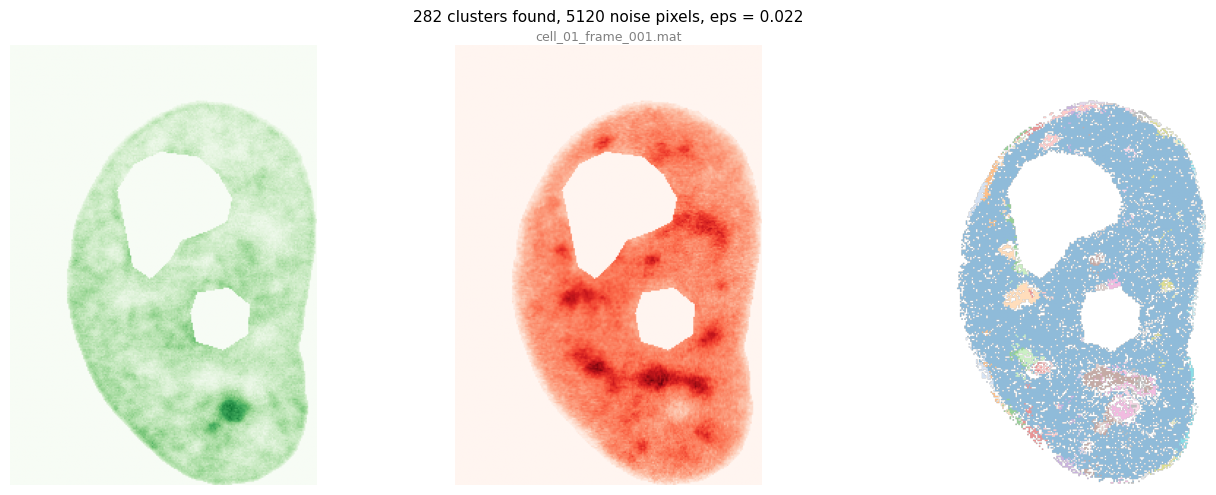

In [ ]:
# --- Validation Set ---
idx = 299 # 0 to 299
EPS = 0.022 #Determined from above
MIN_SAMPLES = 5
features = val_dataset[idx].numpy()
labels   = run_dbscan_on_frame(features, eps=EPS, min_samples=MIN_SAMPLES, channel = 'both') 
n_clusters, n_noise = visualize_clusters(features, labels, EPS, frame_name=train_dataset.file_list[0])

## DBSCAN with just GFP signal

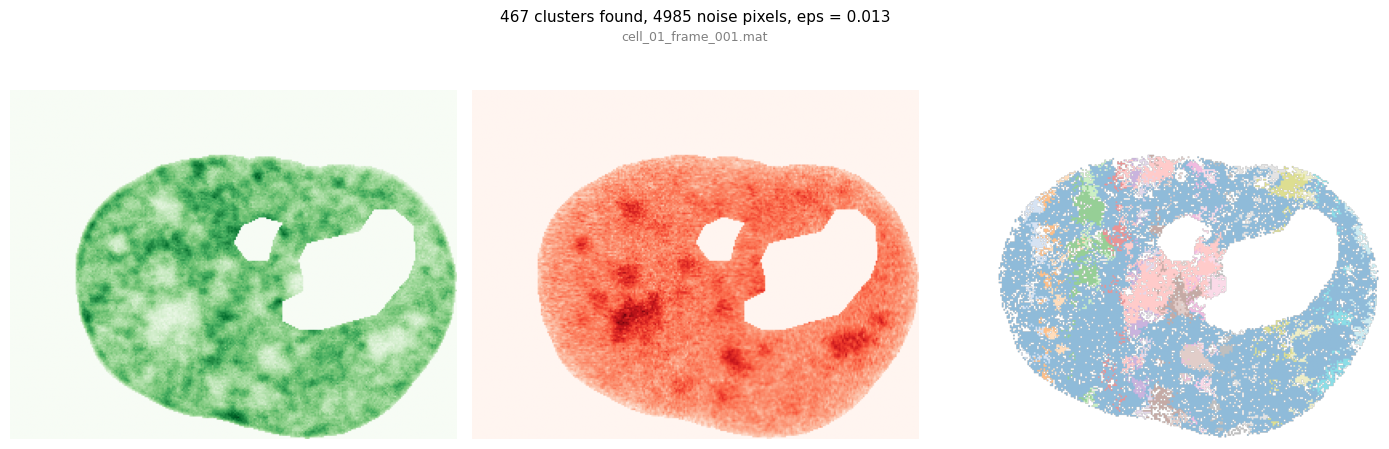

In [ ]:
# --- Run on a single frame to tune eps and min_samples ---
idx = 100 # 0 to 999
EPS = 0.013
MIN_SAMPLES = 5
features = train_dataset[idx].numpy()
labels   = run_dbscan_on_frame(features, eps=EPS, min_samples=MIN_SAMPLES, channel = 'gfp') 
n_clusters, n_noise = visualize_clusters(features, labels, EPS, frame_name=train_dataset.file_list[0])

## DBSCAN with just RFP signal

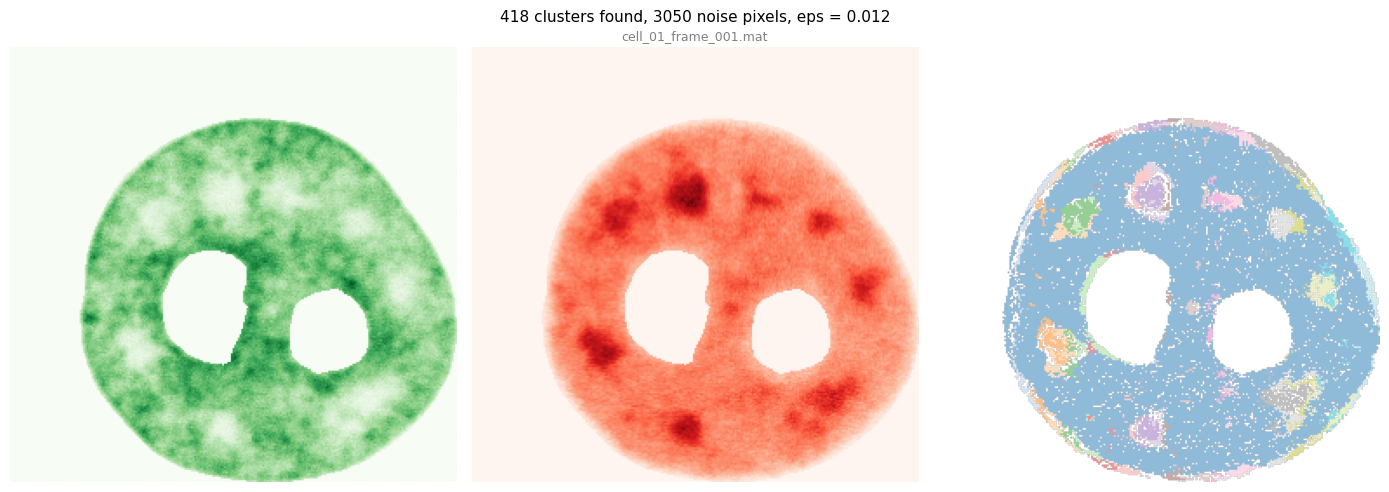

In [ ]:
# --- Run on a single frame to tune eps and min_samples ---
idx = 400 # 0 to 999
EPS = 0.012
MIN_SAMPLES = 5
features = train_dataset[idx].numpy()
labels   = run_dbscan_on_frame(features, eps=EPS, min_samples=MIN_SAMPLES, channel = 'rfp') #0.13 has given me something, as has 0.15
n_clusters, n_noise = visualize_clusters(features, labels, EPS, frame_name=train_dataset.file_list[0])

## Other Interesting Plots

In [41]:
#  Check how changing epsilon values changes noise pixels fraction and number of clusters
from tqdm import tqdm
def plot_epsilon_sweep(eps_values, avg_clusters, avg_noise_frac):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(eps_values, avg_clusters, marker='o')
    axes[0].axvline(0.022, color='red', linestyle='--', label='chosen $\\epsilon$')
    axes[0].axvline(0.05,  color='gray', linestyle='--', label='speckle diameter')
    axes[0].set_xlabel('$\\epsilon$')
    axes[0].set_ylabel('Average cluster count')
    axes[0].set_title('Cluster count vs $\\epsilon$')
    axes[0].legend()

    axes[1].plot(eps_values, avg_noise_frac * 100, marker='o', color='orange')
    axes[1].axvline(0.022, color='red', linestyle='--', label='chosen $\\epsilon$')
    axes[1].axvline(0.05,  color='gray', linestyle='--', label='speckle diameter')
    axes[1].set_xlabel('$\\epsilon$')
    axes[1].set_ylabel('Noise pixel fraction (%)')
    axes[1].set_title('Noise fraction vs $\\epsilon$')
    axes[1].legend()

    fig.suptitle(f'Epsilon sweep over validation set', fontsize=12)
    plt.tight_layout()
    plt.show()

[0.001      0.00357895 0.00615789 0.00873684 0.01131579 0.01389474
 0.01647368 0.01905263 0.02163158 0.02421053 0.02678947 0.02936842
 0.03194737 0.03452632 0.03710526 0.03968421 0.04226316 0.04484211
 0.04742105 0.05      ]


Sweeping epsilon: 100%|██████████| 20/20 [00:02<00:00,  7.67it/s]


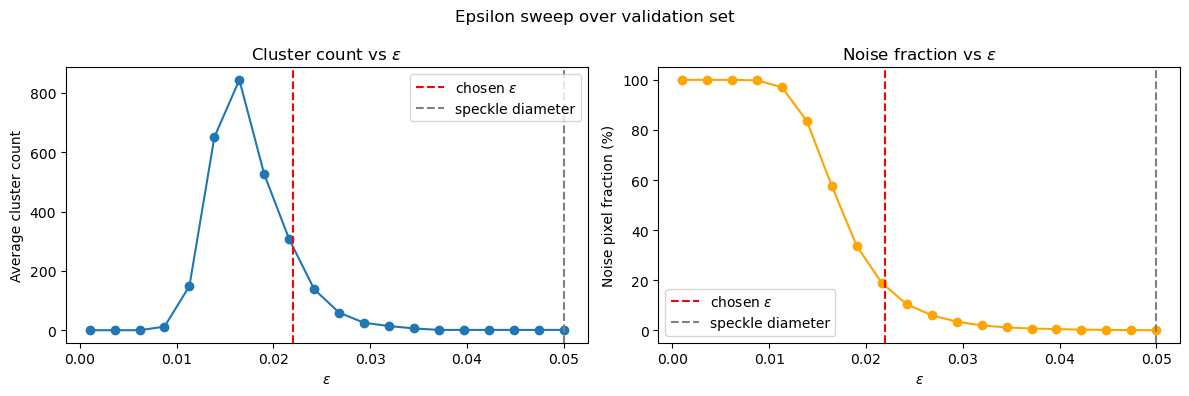

In [43]:
eps_values = np.linspace(0.001, 0.05, 20)
print(eps_values)

# Single frame from validation set
idx  = 299
features = val_dataset[idx].numpy()

n_clusters_all = []
noise_frac_all = []

for eps in tqdm(eps_values, desc='Sweeping epsilon'):
    labels = run_dbscan_on_frame(features, eps=eps, min_samples=5)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).sum() / len(labels)
    n_clusters_all.append(n_clusters)
    noise_frac_all.append(noise_frac)

plot_epsilon_sweep(eps_values, np.array(n_clusters_all), np.array(noise_frac_all))

In [ ]:
"hi"

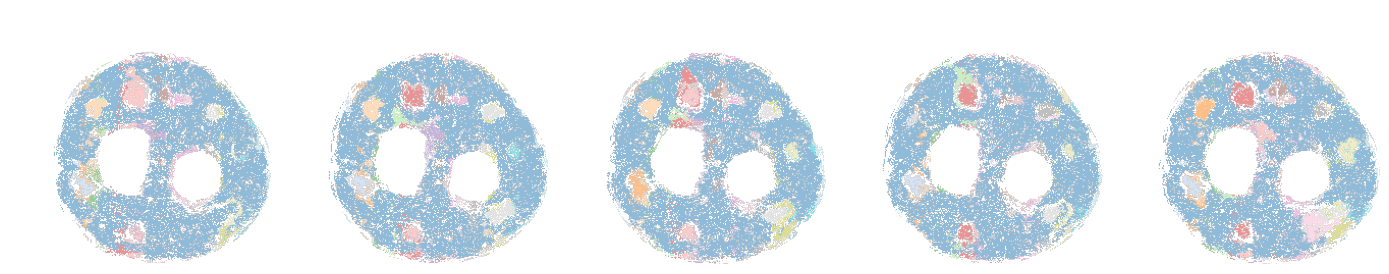

In [44]:
# Visualize clusters for 5 consecutive frames
idx = 400 # 0 to 299
EPS = 0.022 #Determined from above
MIN_SAMPLES = 5
count = 0
fig, axes = plt.subplots(1, 5, figsize=(14, 5))
for i in range(idx, idx + 5):
    features = train_dataset[i].numpy()
    labels = run_dbscan_on_frame(features, eps=EPS, min_samples=MIN_SAMPLES, channel='both')
    n_clusters, n_noise =visualize_ONLY_clusters(fig, axes, count, features, labels, EPS)
    count += 1
   # fig, axes,i, features, labels, EPS, frame_name=''
#fig.suptitle(f'eps={EPS}, min_samples={MIN_SAMPLES}', fontsize=11)
plt.tight_layout()
plt.show()